### **Import Libraries**

In [31]:
import kagglehub
import pandas as pd
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout

### **Load And Explore**

In [32]:
# 1 - Load the dataset

path= kagglehub.dataset_download("shanegerami/ai-vs-human-text")
print(path)
files = os.listdir(path)
csv_file_path = os.path.join(path, files[0])
df = pd.read_csv(csv_file_path)
df=df.sample(n=10000, random_state=42)
# The original dataset is very large, so a sample of 10,000 records was used to
# reduce computational cost and execution time.

# 2 - Print the first 5 rows
display('first 5 rows:',df.head())

# 3 - Check the shape
print('\nCheck the shape:',df.shape)

# 4 - Check for missing values
print('\nCheck for missing values:',df.isnull().sum())

# 5 - Check class balance
print('\nCheck class balance:',df['generated'].value_counts())
# 0.0 Human
# 1.0 Ai

# The dataset is imbalanced because one class contains more samples than the other.
# So, F1-score was used as the primary evaluation metric instead of accuracy.

Using Colab cache for faster access to the 'ai-vs-human-text' dataset.
/kaggle/input/ai-vs-human-text


'first 5 rows:'

,text,generated
419952,"Real or Fake Feelings\n\n""Imagine being able t...",0.0
478535,Seeking multiple opinions can help you make be...,0.0
133753,"ADDRESS_NAME\n\nFebruary 9, 2011\n\nDear TEACH...",0.0
68011,"Dear, TEACHER_NAME,\n\nTEACHER_NAME I Believe ...",0.0
195939,Do you believe that there is a computer that c...,0.0



Check the shape: (10000, 2)

Check for missing values: text         0
generated    0
dtype: int64

Check class balance: generated
0.0    6194
1.0    3806
Name: count, dtype: int64


### **Prepare the Data**

In [33]:
from sklearn.model_selection import train_test_split
# 1 - Identify the axes
X = df['text']
y = df['generated']

# 2 - Dividing the data set into train and test
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.5, random_state=42, stratify=y
)

In [34]:
"""
Text datasets only: clean the text
"""
import re, nltk
from nltk.corpus import stopwords
# 1 - Download English stop words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 2 - Cleaning function
def clean(text):
 text = text.lower()# Converting text to lowercase letters
 text = re.sub(r'[^a-z\s]', '', text) # Delete any non-English character or distance
 words = [w for w in text.split() if w not in stop_words]
 return ' '.join(words)

#  3 - Applying the cleaning function to the data set
df['clean_text'] = df['text'].apply(clean)

"""
Convert text to numbers with TF-IDF
"""
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000) # 1 - Create a tfidf
X_train = tfidf.fit_transform(X_train) # 2 - Learn vocab on train only and convert training data into numbers
X_test = tfidf.transform(X_test) # 3 - apply to test convert training data into numbers

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### **Train and Compare Models**

Logistic Regression Model

In [35]:
# Train the Logistic Regression Model
model1=LogisticRegression()
model1.fit(X_train,y_train)

# Logistic Regression Model Prediction
logis_pred=model1.predict(X_test)

Random Forest Model

In [36]:
# Train the Random Forest Model
model2=RandomForestClassifier()
model2.fit(X_train,y_train)

# Random Forest Model Prediction
rndm_pred=model2.predict(X_test)

KNN Model

In [37]:
# Train the KNN Model
model3=KNeighborsClassifier()
model3.fit(X_train,y_train)

# KNN Model Prediction
knn_pred=model3.predict(X_test)

Accuracy

In [38]:
print('Logistic Regression Accuracy:',accuracy_score(y_test,logis_pred))
print('\nRandom Forest Accuracy:',accuracy_score(y_test,rndm_pred))
print('\nKNN Accuracy:',accuracy_score(y_test,knn_pred))

Logistic Regression Accuracy: 0.9664

Random Forest Accuracy: 0.9576

KNN Accuracy: 0.9164


Precision

In [39]:
print('Logistic Regression Precision:',precision_score(y_test,logis_pred))
print('\nRandom Forest Precision:',precision_score(y_test,rndm_pred))
print('\nKNN Precision:',precision_score(y_test,knn_pred))

Logistic Regression Precision: 0.9774353329664281

Random Forest Precision: 0.993002915451895

KNN Precision: 0.9235596120935539


Recall

In [40]:
print('Logistic Regression Recall:',recall_score(y_test,logis_pred))
print('\nRandom Forest Recall:',recall_score(y_test,rndm_pred))
print('\nKNN Recall:',recall_score(y_test,knn_pred))

Logistic Regression Recall: 0.9332632685233841

Random Forest Recall: 0.8949027850761955

KNN Recall: 0.8507619548081976


F1-score

In [41]:
print('Logistic Regression F1-score:',f1_score(y_test,logis_pred))
print('\nRandom Forest F1-score:',f1_score(y_test,rndm_pred))
print('\nKNN F1-score:',f1_score(y_test,knn_pred))

Logistic Regression F1-score: 0.9548387096774194

Random Forest F1-score: 0.941404090657822

KNN F1-score: 0.8856673960612691


### **Plot A Confusion Matrix For Each Model**

In [42]:
cm1=confusion_matrix(y_test,logis_pred)
cm2=confusion_matrix(y_test,rndm_pred)
cm3=confusion_matrix(y_test,knn_pred)

The cmap colors used in this heatmap were inspired by
https://matplotlib.org/stable/users/explain/colors/colormaps.html

<function matplotlib.pyplot.show(close=None, block=None)>

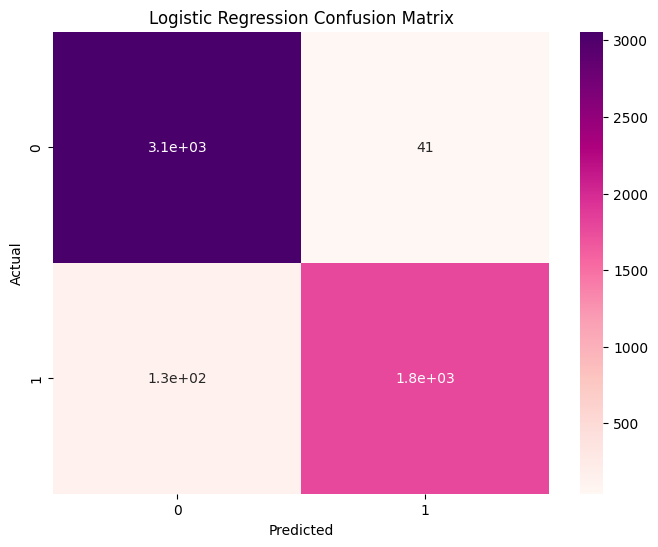

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(cm1,annot=True,cmap='RdPu')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

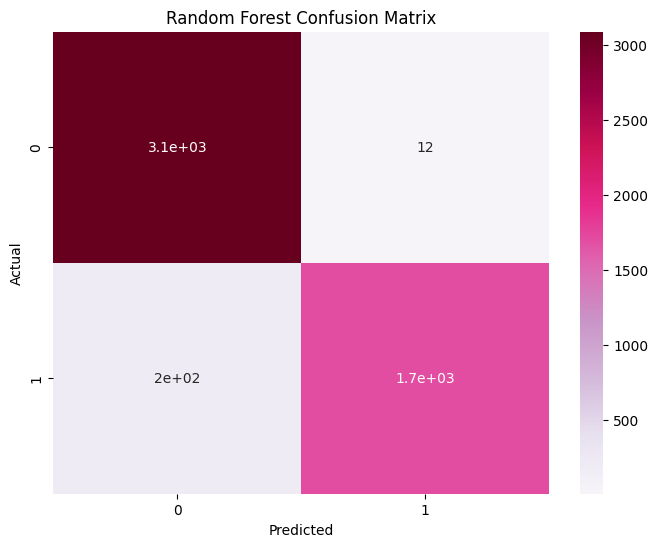

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(cm2,annot=True,cmap='PuRd')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

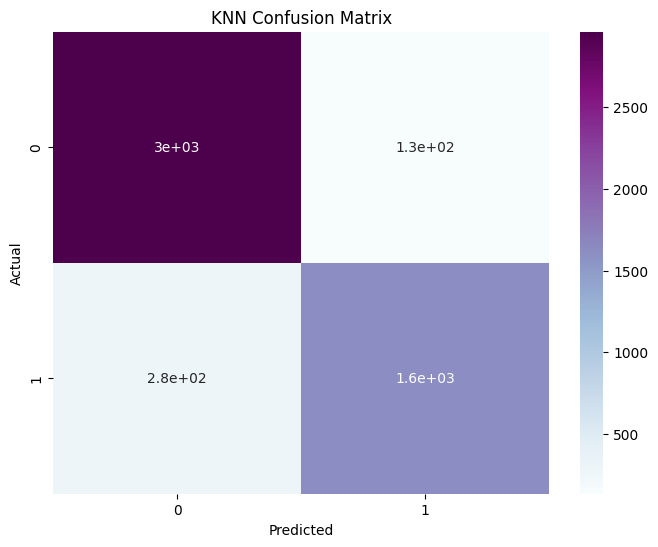

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(cm3,annot=True,cmap='BuPu')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

In [46]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.9664,
        "Precision": 0.9774353329664281,
        "Recall": 0.9332632685233841,
        "F1-score": 0.9548387096774194
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.9548,
        "Precision": 0.9912126537785588,
        "Recall": 0.8891224382553863,
        "F1-score": 0.9373961218836565
    },
    {
        "Model": "KNN",
        "Accuracy": 0.9164,
        "Precision": 0.9235596120935539,
        "Recall": 0.8507619548081976,
        "F1-score": 0.8856673960612691
    }
]
results_df = pd.DataFrame(results)
print(f"results_df\n{results_df}")

results_df
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression    0.9664   0.977435  0.933263  0.954839
1        Random Forest    0.9548   0.991213  0.889122  0.937396
2                  KNN    0.9164   0.923560  0.850762  0.885667


In [47]:
The_best_model = results_df.loc[results_df["F1-score"].idxmax()]

print(f"The_Best Model:{The_best_model["Model"]}")

The_Best Model:Logistic Regression


### **Neural Network**

In [48]:
"""first Neural Network"""
model_1 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1, activation="sigmoid"), # One neuron for binary classification
])

#  1 - Assembly of the first model
model_1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#  2 - Training the first model using the original training data
history_1 = model_1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8710 - loss: 0.3637 - val_accuracy: 0.9644 - val_loss: 0.1602
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9822 - loss: 0.0968 - val_accuracy: 0.9742 - val_loss: 0.0870
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9916 - loss: 0.0468 - val_accuracy: 0.9798 - val_loss: 0.0645
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9970 - loss: 0.0267 - val_accuracy: 0.9828 - val_loss: 0.0557
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9984 - loss: 0.0166 - val_accuracy: 0.9842 - val_loss: 0.0513
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9994 - loss: 0.0108 - val_accuracy: 0.9844 - val_loss: 0.0497
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9998 - loss: 0.0074 - val_accuracy: 0.9846 - val_loss: 0.0486
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accu

In [49]:
"""second Neural Network"""

# 1 - Convert labels to One-Hot Encoding
# Because neural networks calculate that 1 and 0 have a order, we did One-Hot Encoding
y_train_oh = to_categorical(y_train, num_classes=2)
y_test_oh = to_categorical(y_test, num_classes=2)

model_2 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3), # Arrest30% to reduce overfitting
    Dense(2, activation="softmax"), # two neuron for categorical_crossentropy
])

# 2 - Assembly of the second model
model_2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

#  3 - Training the first model using the original training data
history_2 = model_2.fit(X_train, y_train_oh, epochs=10, validation_data=(X_test, y_test_oh))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8416 - loss: 0.3879 - val_accuracy: 0.9598 - val_loss: 0.1796
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9774 - loss: 0.1192 - val_accuracy: 0.9746 - val_loss: 0.0952
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9882 - loss: 0.0605 - val_accuracy: 0.9768 - val_loss: 0.0704
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9932 - loss: 0.0406 - val_accuracy: 0.9808 - val_loss: 0.0600
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9956 - loss: 0.0283 - val_accuracy: 0.9806 - val_loss: 0.0566
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9976 - loss: 0.0185 - val_accuracy: 0.9836 - val_loss: 0.0520
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9988 - loss: 0.0129 - val_accuracy: 0.9832 - val_loss: 0.0525
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9990 - loss: 0.0103 - val_accu

### **Plot the training vs. validation loss and accuracy curves**

The training loss and validation loss both decreased and stayed very close together, which means the model learned well and there are no clear signs of overfitting.

Text(0.5, 1.0, 'Model 1 Loss')

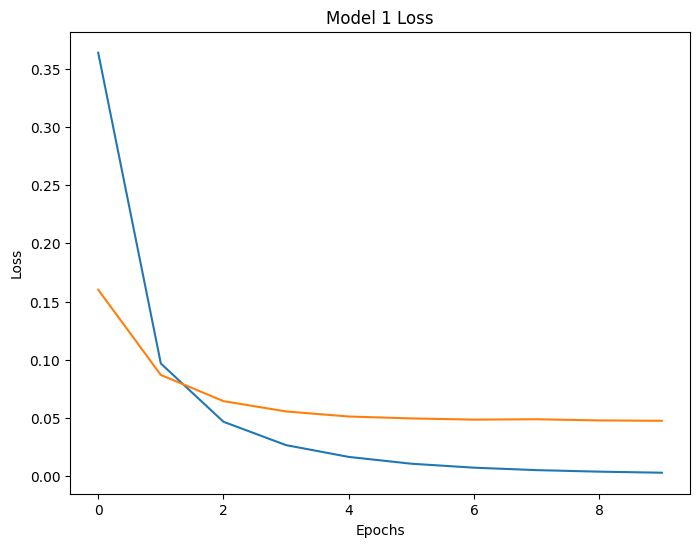

In [50]:
plt.figure(figsize=(8,6))
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model 1 Loss')

Text(0.5, 1.0, 'Model 2 Loss')

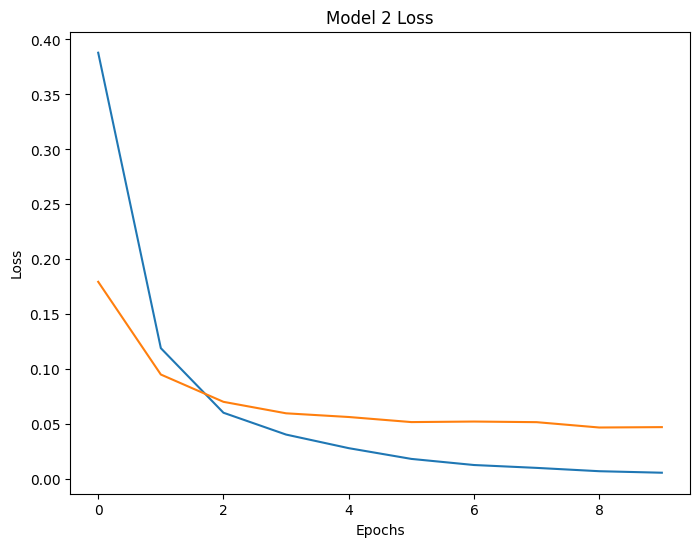

In [51]:
plt.figure(figsize=(8,6))
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model 2 Loss')

The training accuracy and validation accuracy reached very high values and remained close together, indicating that the model performed consistently on both training and validation data.

Text(0.5, 1.0, 'Model 1 Accuracy')

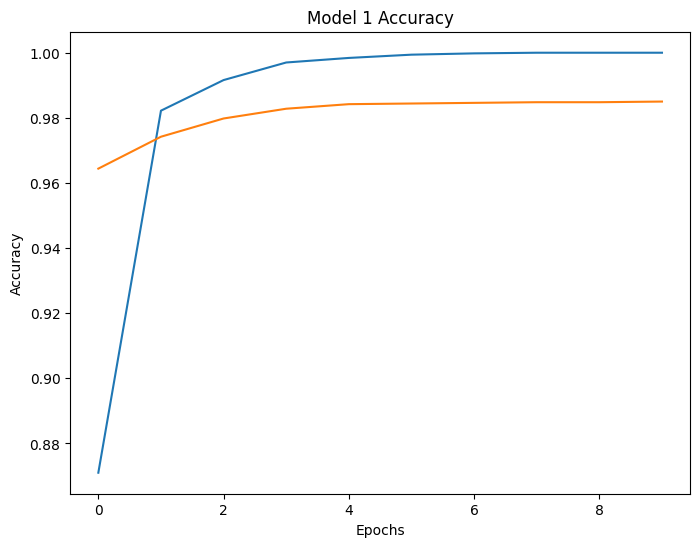

In [52]:
plt.figure(figsize=(8,6))
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model 1 Accuracy')

Text(0.5, 1.0, 'Model 2 Accuracy')

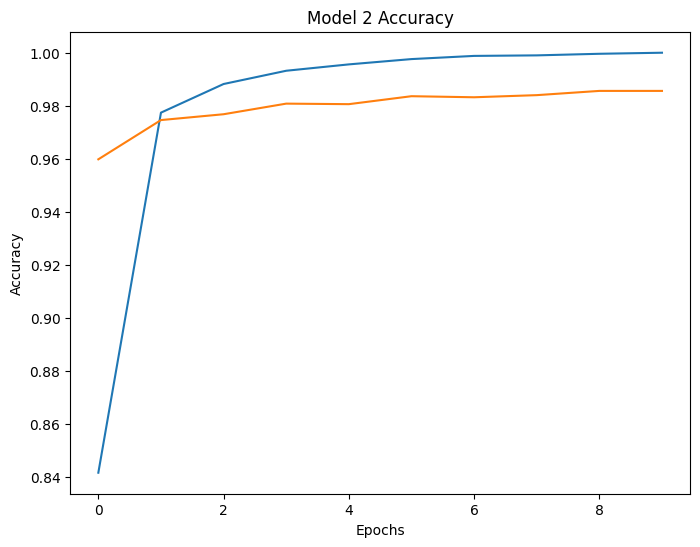

In [53]:
plt.figure(figsize=(8,6))
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model 2 Accuracy')

### **Evaluate the neural network using the same metrics as Step 1**

In [54]:
nn1_pred=model_1.predict(X_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [55]:
nn2_pred=model_2.predict(X_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [56]:
nn1_pred_binary=(nn1_pred>0.5).astype(int)
# We used (nn_pred > 0.5).astype(int) to convert the model’s probability outputs (from sigmoid) into final binary classes (0 or 1),
# because the confusion matrix requires discrete predictions instead of probabilities.
print('Neural Network Accuracy:',round(accuracy_score(y_test,nn1_pred_binary),2))
print('\nNeural Network Precision:',round(precision_score(y_test,nn1_pred_binary),2))
print('\nNeural Network Recall:',round(recall_score(y_test,nn1_pred_binary),2))
print('\nNeural Network F1-score:',round(f1_score(y_test,nn1_pred_binary),2))

Neural Network Accuracy: 0.98

Neural Network Precision: 0.99

Neural Network Recall: 0.97

Neural Network F1-score: 0.98


In [57]:
nn2_pred_binary=np.argmax(nn2_pred, axis=1)
# We used `np.argmax(nn2_pred, axis=1)` to convert the model’s softmax probability outputs into final class labels
# by selecting the index of the highest probability for each sample, since evaluation metrics require discrete predictions instead of probability distributions.

print('Neural Network Accuracy:',round(accuracy_score(y_test,nn2_pred_binary),2))
print('\nNeural Network Precision:',round(precision_score(y_test,nn2_pred_binary),2))
print('\nNeural Network Recall:',round(recall_score(y_test,nn2_pred_binary),2))
print('\nNeural Network F1-score:',round(f1_score(y_test,nn2_pred_binary),2))

Neural Network Accuracy: 0.99

Neural Network Precision: 0.99

Neural Network Recall: 0.97

Neural Network F1-score: 0.98


### **Add neural network results to the Step 1 summary table.**

In [58]:
results.append({
    "Model": "Neural Network 1",
    "Accuracy": 0.99,
    "Precision": 0.99,
    "Recall": 0.97,
    "F1-score": 0.98
})
results.append({
    "Model": "Neural Network 2",
    "Accuracy": 0.99,
    "Precision": 0.99,
    "Recall": 0.97,
    "F1-score": 0.98
})
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9664,
  'Precision': 0.9774353329664281,
  'Recall': 0.9332632685233841,
  'F1-score': 0.9548387096774194},
 {'Model': 'Random Forest',
  'Accuracy': 0.9548,
  'Precision': 0.9912126537785588,
  'Recall': 0.8891224382553863,
  'F1-score': 0.9373961218836565},
 {'Model': 'KNN',
  'Accuracy': 0.9164,
  'Precision': 0.9235596120935539,
  'Recall': 0.8507619548081976,
  'F1-score': 0.8856673960612691},
 {'Model': 'Neural Network 1',
  'Accuracy': 0.99,
  'Precision': 0.99,
  'Recall': 0.97,
  'F1-score': 0.98},
 {'Model': 'Neural Network 2',
  'Accuracy': 0.99,
  'Precision': 0.99,
  'Recall': 0.97,
  'F1-score': 0.98}]

### **Comparison Between Neural Network and Machine Learning Models.**


*   The neural network made fewer classification errors compared to the machine learning models.
*   After training the models, it became clear that the best model used was the neural network.